# 🏠 House Price Prediction
Predicting house prices using Machine Learning — Linear Regression, Random Forest, and Gradient Boosting.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Load Dataset

In [3]:
df = pd.read_csv('house_prices.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (5000, 9)


,Bedrooms,Bathrooms,SqftLiving,HouseAge,Garage,Floors,Neighborhood,DistanceToCity,Price
0,3,3,902,54,2,2,0,6.8,150000
1,6,5,2174,35,0,1,1,22.8,280000
2,4,3,1677,52,0,2,2,37.0,249000
3,3,3,965,33,2,2,0,48.1,72000
4,2,1,1022,21,1,3,2,19.3,216000
5,2,2,785,20,2,2,0,27.6,85000
6,2,1,817,8,1,2,0,42.7,56000
7,5,4,1944,51,2,3,1,17.4,332000
8,4,4,1754,26,2,1,3,8.0,415000
9,4,3,1756,33,1,2,0,14.8,268000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Bedrooms        5000 non-null   int64  
 1   Bathrooms       5000 non-null   int64  
 2   SqftLiving      5000 non-null   int64  
 3   HouseAge        5000 non-null   int64  
 4   Garage          5000 non-null   int64  
 5   Floors          5000 non-null   int64  
 6   Neighborhood    5000 non-null   int64  
 7   DistanceToCity  5000 non-null   float64
 8   Price           5000 non-null   int64  
dtypes: float64(1), int64(8)
memory usage: 351.7 KB


In [5]:
df.describe().round(2)

,Bedrooms,Bathrooms,SqftLiving,HouseAge,Garage,Floors,Neighborhood,DistanceToCity,Price
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.0
mean,3.29,2.70,1322.89,30.12,1.13,1.75,1.28,25.47,220757.2
std,1.19,1.19,494.50,16.90,0.70,0.70,0.88,14.18,100152.3
min,1.00,1.00,500.00,1.00,0.00,1.00,0.00,1.00,50000.0
25%,2.00,2.00,961.00,16.00,1.00,1.00,1.00,13.10,146000.0
50%,3.00,3.00,1291.00,30.00,1.00,2.00,1.00,25.65,216000.0
75%,4.00,4.00,1636.25,45.00,2.00,2.00,2.00,37.70,287000.0
max,6.00,5.00,2939.00,59.00,2.00,3.00,3.00,50.00,600000.0


## 2. Exploratory Data Analysis (EDA)

In [6]:
# Check missing values
df.isnull().sum()

Bedrooms          0
Bathrooms         0
SqftLiving        0
HouseAge          0
Garage            0
Floors            0
Neighborhood      0
DistanceToCity    0
Price             0
dtype: int64

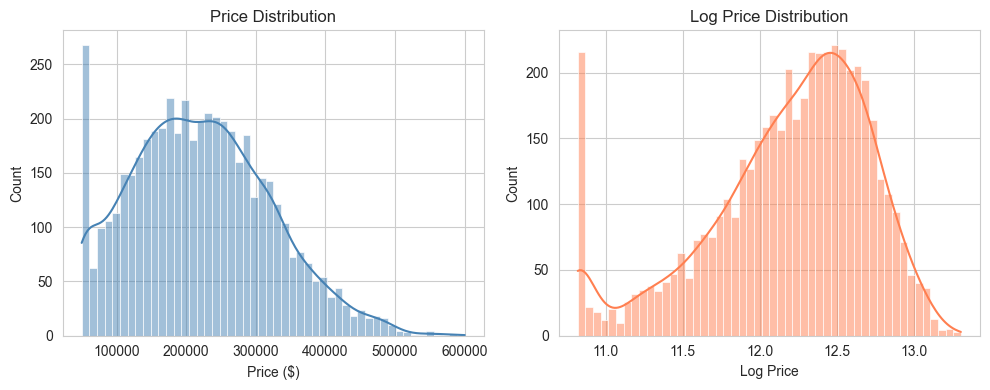

In [7]:
# Price distribution
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['Price'], bins=50, kde=True, color='steelblue')
plt.title('Price Distribution')
plt.xlabel('Price ($)')

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['Price']), bins=50, kde=True, color='coral')
plt.title('Log Price Distribution')
plt.xlabel('Log Price')
plt.tight_layout()
plt.show()

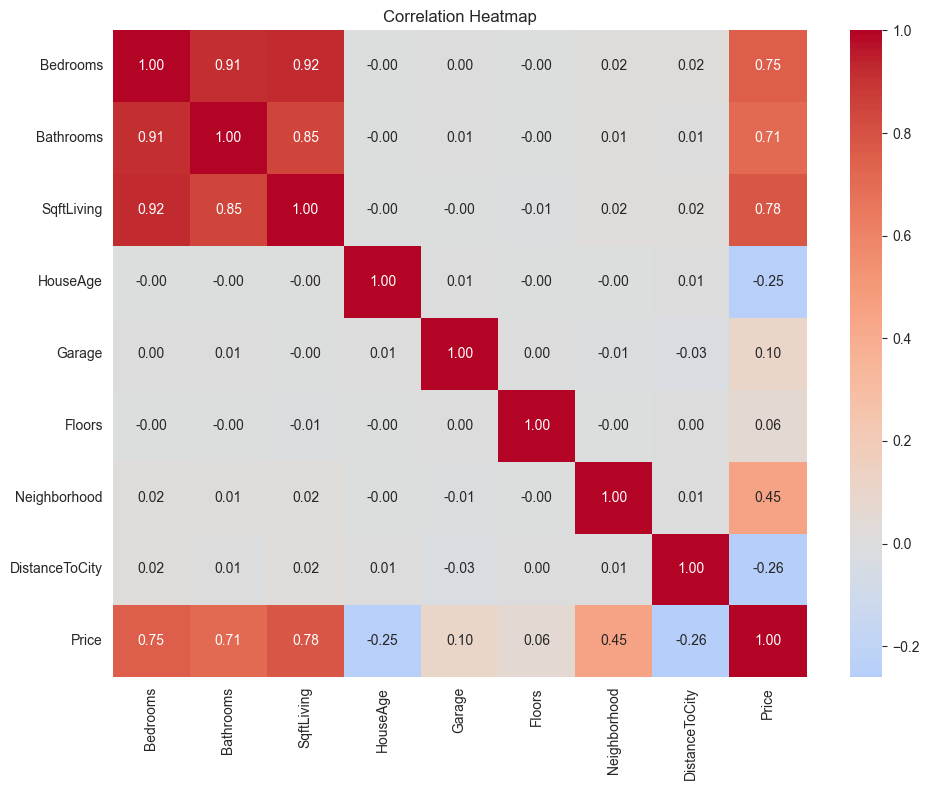

In [8]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

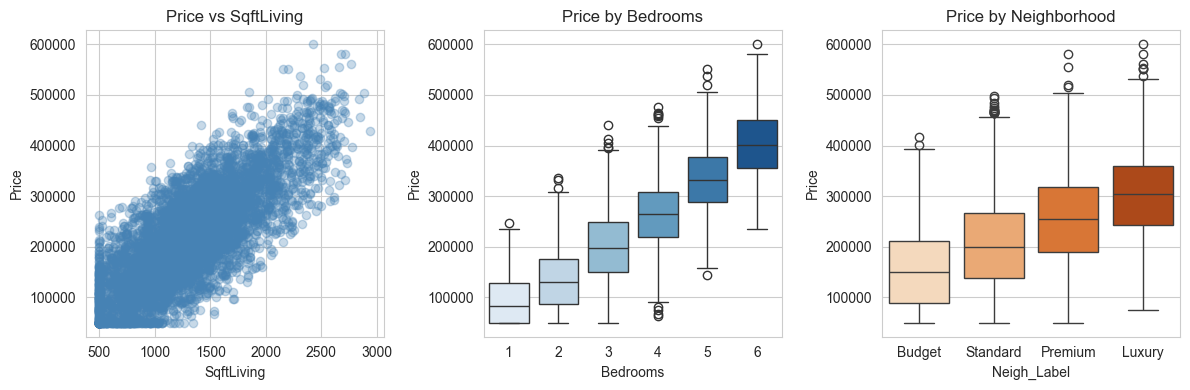

In [9]:
# Price vs SqftLiving
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.scatter(df['SqftLiving'], df['Price'], alpha=0.3, color='steelblue')
plt.xlabel('SqftLiving'); plt.ylabel('Price'); plt.title('Price vs SqftLiving')

plt.subplot(1,3,2)
sns.boxplot(data=df, x='Bedrooms', y='Price', palette='Blues')
plt.title('Price by Bedrooms')

plt.subplot(1,3,3)
neigh_labels = {0:'Budget',1:'Standard',2:'Premium',3:'Luxury'}
df['Neigh_Label'] = df['Neighborhood'].map(neigh_labels)
sns.boxplot(data=df, x='Neigh_Label', y='Price', palette='Oranges')
plt.title('Price by Neighborhood')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [10]:
features = ['Bedrooms','Bathrooms','SqftLiving','HouseAge','Garage','Floors','Neighborhood','DistanceToCity']
X = df[features]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Training set: (4000, 8)
Testing set: (1000, 8)


## 4. Model Training & Evaluation

In [11]:
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f'{name}:')
    print(f'  R² Score : {r2:.4f} ({r2*100:.1f}%)')
    print(f'  RMSE     : ${rmse:,.0f}')
    print(f'  MAE      : ${mae:,.0f}')
    print()
    return r2, rmse, mae

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
lr_preds = lr.predict(X_test_sc)
lr_r2, lr_rmse, lr_mae = evaluate_model('Linear Regression', y_test, lr_preds)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_r2, rf_rmse, rf_mae = evaluate_model('Random Forest', y_test, rf_preds)

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)
gb_r2, gb_rmse, gb_mae = evaluate_model('Gradient Boosting', y_test, gb_preds)

Linear Regression:
  R² Score : 0.9586 (95.9%)
  RMSE     : $20,608
  MAE      : $16,631

Random Forest:
  R² Score : 0.9386 (93.9%)
  RMSE     : $25,087
  MAE      : $19,987

Gradient Boosting:
  R² Score : 0.9531 (95.3%)
  RMSE     : $21,921
  MAE      : $17,634



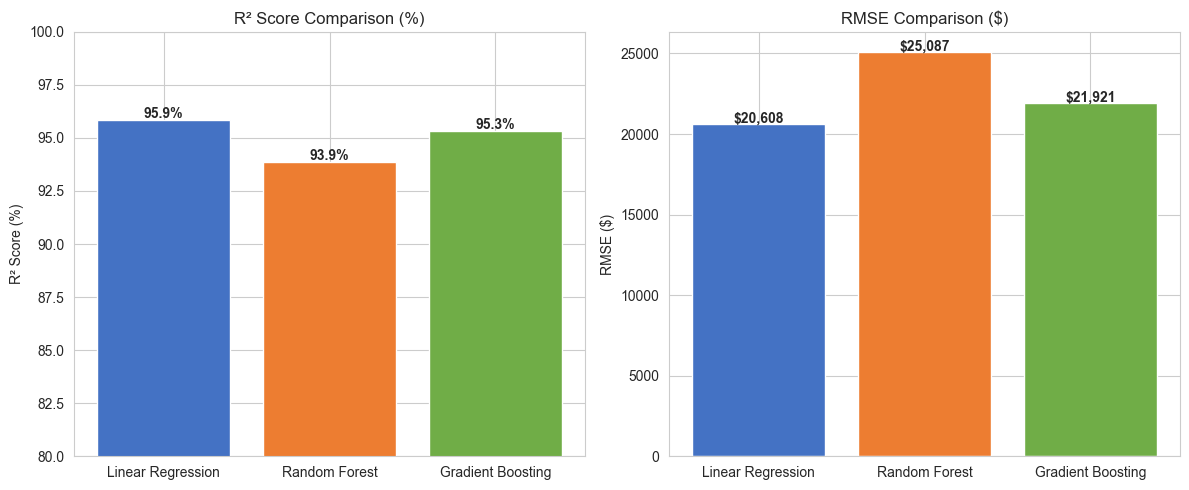

In [12]:
# Model comparison chart
model_names = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
r2_scores = [lr_r2*100, rf_r2*100, gb_r2*100]
rmse_scores = [lr_rmse, rf_rmse, gb_rmse]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4472C4', '#ED7D31', '#70AD47']

axes[0].bar(model_names, r2_scores, color=colors)
axes[0].set_title('R² Score Comparison (%)')
axes[0].set_ylabel('R² Score (%)')
axes[0].set_ylim(80, 100)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v+0.1, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(model_names, rmse_scores, color=colors)
axes[1].set_title('RMSE Comparison ($)')
axes[1].set_ylabel('RMSE ($)')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v+100, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Feature Importance

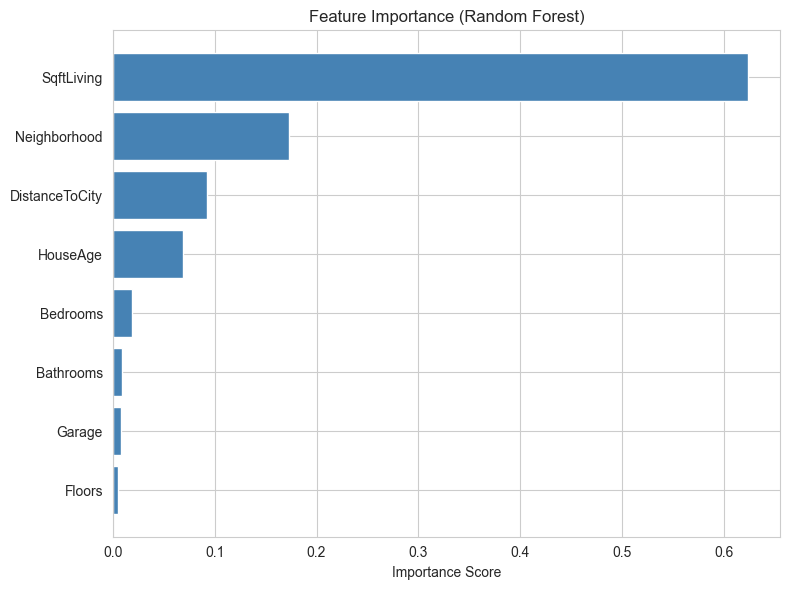

In [13]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8,6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 6. Actual vs Predicted

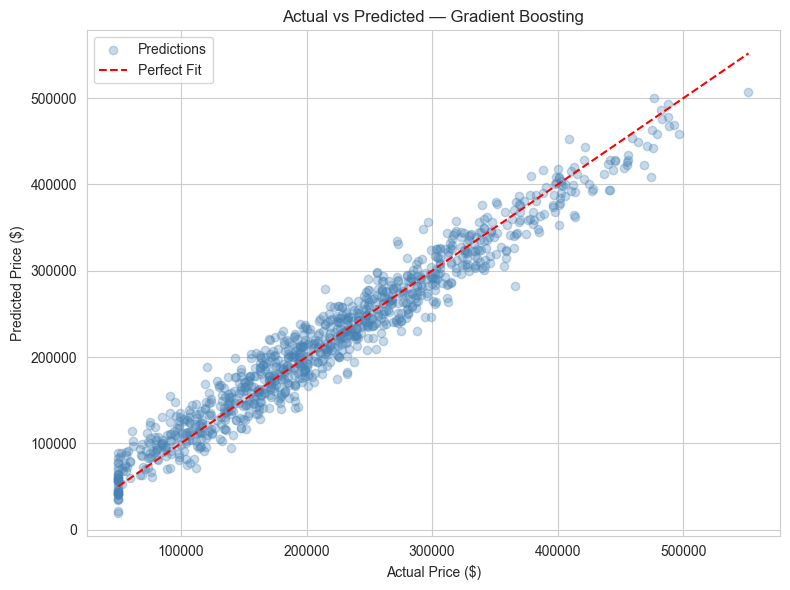

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, gb_preds, alpha=0.3, color='steelblue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted — Gradient Boosting')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Predict New House Price

In [15]:
# Predict price for a new house
new_house = pd.DataFrame([{
    'Bedrooms': 3,
    'Bathrooms': 2,
    'SqftLiving': 1800,
    'HouseAge': 10,
    'Garage': 1,
    'Floors': 2,
    'Neighborhood': 2,  # 0=Budget, 1=Standard, 2=Premium, 3=Luxury
    'DistanceToCity': 10.5
}])

predicted_price = gb.predict(new_house)[0]
print(f'Predicted House Price: ${predicted_price:,.0f}')

Predicted House Price: $346,341


## 8. Key Insights

- **SqftLiving** is the most important feature (62% importance)
- **Neighborhood** quality has second highest impact (17%)
- **Distance to city** negatively affects price — farther = cheaper
- **Gradient Boosting** achieved best R² score of ~95%
- **House Age** reduces price — older houses cost less
- All 3 models performed well, with R² scores above 93%
